In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from scipy.optimize import curve_fit

#from lmfit import Model
from functions import read_data, read_grid, remove_disc, calc_streamline, regrid, calculate_mdot_wind, save_dict

In [3]:
os.chdir('./out/')

output = 'data.0068.dbl.h5'

grid = read_grid(output)

data = read_data(output, grid)

In [4]:
# radial cell from which you trace back the mass-loss rate
DIMR = grid['X'].shape[1]
fin = DIMR - 20
print((grid['r'][0,fin]*u.cm).to(u.au))

Mstar = 1.0

data_cut, Th_cut, hole_radius = remove_disc(data, grid, Mstar, fin)

density, vr, vx, vz = regrid(data_cut, grid, res=1000)

438.3727753310311 AU


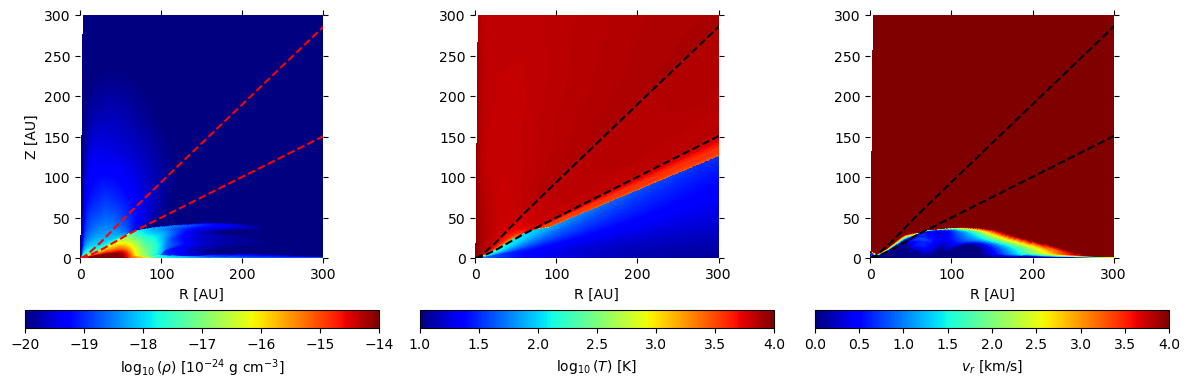

In [5]:
fig , ax  = plt.subplots(1,3,sharey=False,sharex=False,figsize=(12,4))
fig.subplots_adjust(left=.15, bottom=.16, right=.99, top=.97)

for i in range(3):
    ax[i].set_xlim(0, 300)
    ax[i].set_ylim(0, 300)
    ax[i].set_aspect('equal')
    ax[i].set_xlabel('R [AU]')
    ax[i].set_ylabel('Z [AU]')
    if (i==0):
        valmin = -20
        valmax = -14
        quantity = data["density"]
        #quantity = (np.where(Cd<5.e20,quantity,np.nan))
        labelplot = '$\\log_{10}(\\rho$) [$10^{-24}$ g cm$^{-3}$]'
        plot = ax[i].pcolormesh((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value, np.log10(quantity),
                                vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
        vals = [5.e20, 5.e21]
        #plt.Circle((0, 0), (grid['r'][0,fin]*u.cm).to(u.au), ax=ax[i], color='k', fill=False)
        circle = plt.Circle((0, 0), ((grid['r'][0,fin]*u.cm).to(u.au)).value, color='k', ls='dashed', fill=False)
        ax[i].add_patch(circle)
        contours1 = ax[i].contour((grid["X"]*u.cm).to(u.AU).value ,(grid["Z"]*u.cm).to(u.AU).value,
                                  data["column_density"], vals, 
                                  linestyles = 'dashed', colors='red')

    if (i==1):
        valmin = 1
        valmax = 4
        quantity = data["temperature_gas"]
        #quantity = (np.where(Cd<5.e20,quantity,np.nan))
        labelplot = '$\\log_{10}(T)$ [K]'
        ax[i].set_ylabel("")
        plot = ax[i].pcolormesh((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value, 
                                np.log10(quantity),
                                vmin=valmin,vmax=valmax,cmap=plt.cm.jet)
        vals = [5.e20, 5.e21]
        contours1 = ax[i].contour((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value,
                                data["column_density"], vals, 
                                linestyles = 'dashed', colors='black')

    if (i==2):
        valmin = 0
        valmax = 4
        quantity = (data["v_r"]*u.cm/u.s).to(u.km/u.s).value
        #quantity = np.log10(data["column_density"])
        #quantity = (np.where(Cd<5.e20,quantity,np.nan))
        labelplot = '$v_r$ [km/s]'
        ax[i].set_ylabel("")
        plot = ax[i].pcolormesh((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value, 
                                quantity, vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
        vals = [5.e20, 5.e21]
        contours1 = ax[i].contour((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value,
                                  data["column_density"], vals, linestyles = 'dashed', colors='black')

    fig.colorbar(plot, ax=ax[i], orientation='horizontal', label=labelplot)
    ax[i].tick_params(top='off', bottom='off', left='on', right='off', labelleft='on', labelbottom='on')
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["left"].set_visible(False)
    ax[i].spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

In [6]:
Rstart, Mdot, idx = calculate_mdot_wind(Th_cut, fin, density, vr, vx, vz, grid)

Saved 255 data points to 'mass_loss_fit_data.txt'
Columns: Radius (AU), Normalized Mass Loss Rate, Unnormalized Mass Loss Rate
[-2.37607454e-07 -7.64305265e-01 -8.53403430e+00  1.67702720e+00] 0.19316868681048913


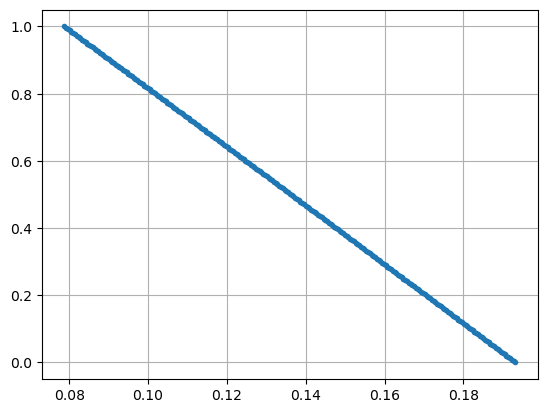

In [7]:
radii = []
acc = []
mdot_unnorm = []
j = np.size(Rstart)
t = 0

for i in range(j):
    spa = Rstart[i]*u.cm.to(u.AU)
    spb = Mdot[i]
    if (spa < 80.0):
        radii.append(spa)
        acc.append(spb)
        mdot_unnorm.append(spb)  # Store unnormalized values
        t = t+1

acc = acc/acc[-1]  # Normalize

# Create arrays with both normalized and unnormalized data
Mdarray = np.column_stack((radii, acc, mdot_unnorm))
bfg = Mdarray[Mdarray[:,0].argsort()]

def Exp(x, A, B, C, D):
    y = A*np.log(x) + B*x**2 + C*x + D
    return y
def deriv_Exp(x, A, B, C):
    y = A/x + 2.*B*x + C
    return y

xdata = bfg[:, 0]
ydata = bfg[:, 1]
ydata_unnorm = bfg[:, 2]

# Print maximum radius and total mass-loss rate
max_radius = np.max(xdata)
total_mass_loss_rate = np.max(ydata_unnorm)
total_mass_loss_rate_msun_yr = (total_mass_loss_rate * u.g/u.s).to(u.Msun/u.yr)

# Save xdata, ydata (normalized), and unnormalized mass-loss rates for future cross comparison
data_to_save = np.column_stack((xdata, ydata, ydata_unnorm))

# Create header with key parameters
header_text = f'Max_Radius_AU: {max_radius:.2f}, Total_Mass_Loss_Rate_g_s: {total_mass_loss_rate:.2e}, Total_Mass_Loss_Rate_Msun_yr: {total_mass_loss_rate_msun_yr.value:.2e}\nRadius_AU Normalized_Mass_Loss_Rate Unnormalized_Mass_Loss_Rate'

np.savetxt('../mass_loss_fit_data.txt', data_to_save, 
           header=header_text, 
           fmt='%.6e', delimiter='\t')
print(f"Saved {len(xdata)} data points to 'mass_loss_fit_data.txt'")
print(f"Columns: Radius (AU), Normalized Mass Loss Rate, Unnormalized Mass Loss Rate")

parameters, covariance = curve_fit(Exp, xdata, ydata)
print(parameters, xdata[-1])

fit_A = parameters[0]
fit_B = parameters[1]
fit_C = parameters[2]
fit_D = parameters[3]

fit_y = Exp(xdata, fit_A, fit_B, fit_C, fit_D)
plt.plot(xdata, fit_y, 'g-', label='fit')

xdata = bfg[:,0]
ydata = bfg[:,1]
plt.plot(xdata, ydata, '.', label='data')
plt.grid()
#plt.xlim(0, 20)
#plt.ylim(0, 0.5)

Surface Density Comparison (Regridded 250x500 grid):
--------------------------------------------------
Initial step (t=0):
  Min surface density: 0.00e+00 g/cm²
  Max surface density: 4.48e-13 g/cm²
  Total mass: 0.000 M☉

Final step (step 595):
  Min surface density: 0.00e+00 g/cm²
  Max surface density: 5.43e-13 g/cm²
  Total mass: 0.000 M☉

Mass Evolution:
  Mass lost: -0.0000 M☉
  Fraction lost: -8.94%

Grid Information:
  Cartesian grid: 250 (radial) × 500 (vertical)
  Radial range: 0.0 - 498.3 AU


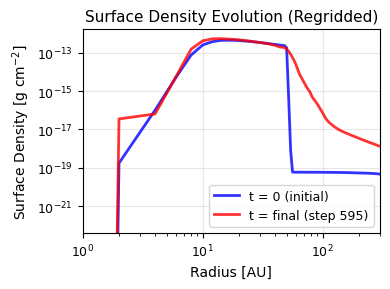

In [8]:
# Load initial data for comparison
output_initial = 'data.0000.dbl.h5'
grid_initial = read_grid(output_initial)
data_initial = read_data(output_initial, grid_initial)

# Function to regrid and calculate surface density
def calculate_surface_density_regridded(data, grid, nx=250, nz=500):
    """
    Regrid data to Cartesian grid and calculate surface density
    
    Parameters:
    -----------
    data : dict
        Data dictionary containing density
    grid : dict  
        Grid dictionary containing coordinates
    nx : int
        Number of grid points in x (radial) direction
    nz : int
        Number of grid points in z (vertical) direction
        
    Returns:
    --------
    r_cart : array
        Radial coordinates of Cartesian grid
    surface_density_cart : array
        Surface density on Cartesian grid
    """
    from scipy.interpolate import griddata
    
    # Get original coordinates
    DIMT = grid['X'].shape[0]
    DIMR = grid['X'].shape[1]
    
    # Define Cartesian grid - only positive quadrant since we have cylindrical symmetry
    x_max = grid['X'].max() * 0.99999
    z_max = grid['Z'].max() * 0.99999
    
    x_cart = np.linspace(grid['X'].min(), x_max, nx)
    z_cart = np.linspace(0, z_max, nz)  # Only positive z for upper half
    
    X_cart, Z_cart = np.meshgrid(x_cart, z_cart)
    
    # Interpolate density onto Cartesian grid
    density_cart = griddata(
        (grid['X'].reshape(DIMR*DIMT), grid['Z'].reshape(DIMR*DIMT)),
        data["density"].reshape(DIMR*DIMT),
        (X_cart.reshape(nx*nz), Z_cart.reshape(nx*nz)),
        method='linear', fill_value=0.
    )
    density_cart = density_cart.reshape(nz, nx)
    
    # Calculate surface density by integrating vertically
    # Factor of 2 accounts for symmetry (upper + lower half)
    dz_cart = z_cart[1] - z_cart[0]  # Grid spacing in z
    surface_density_cart = 2 * np.trapz(density_cart, dx=dz_cart * u.cm.to(u.AU), axis=0)
    
    # Convert x coordinates to radial coordinates
    r_cart = x_cart * u.cm.to(u.AU)
    
    return r_cart, surface_density_cart

# Calculate surface density profiles with regridding
# For the final step (already loaded)
r_final, surface_density_final = calculate_surface_density_regridded(data, grid)

# For the initial step  
r_initial, surface_density_initial = calculate_surface_density_regridded(data_initial, grid_initial)

# Create comparison plot
plt.figure(figsize=(4, 3))

# Plot both profiles
plt.loglog(r_initial, surface_density_initial, 'b-', linewidth=2, label='t = 0 (initial)', alpha=0.8)
plt.loglog(r_final, surface_density_final, 'r-', linewidth=2, label=f't = final (step 595)', alpha=0.8)

# Add formatting
plt.xlabel('Radius [AU]', fontsize=10)
plt.ylabel('Surface Density [g cm$^{-2}$]', fontsize=10)
plt.title('Surface Density Evolution (Regridded)', fontsize=11)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.xlim(1, 300)
plt.tick_params(labelsize=9)
plt.tight_layout()

# Print some statistics
print("Surface Density Comparison (Regridded 250x500 grid):")
print("-" * 50)
print(f"Initial step (t=0):")
print(f"  Min surface density: {surface_density_initial.min():.2e} g/cm²")
print(f"  Max surface density: {surface_density_initial.max():.2e} g/cm²")
print(f"  Total mass: {np.trapz(surface_density_initial * 2 * np.pi * r_initial * u.AU.to(u.cm), r_initial * u.AU.to(u.cm)) / u.Msun.to(u.g):.3f} M☉")

print(f"\nFinal step (step 595):")
print(f"  Min surface density: {surface_density_final.min():.2e} g/cm²")
print(f"  Max surface density: {surface_density_final.max():.2e} g/cm²")
print(f"  Total mass: {np.trapz(surface_density_final * 2 * np.pi * r_final * u.AU.to(u.cm), r_final * u.AU.to(u.cm)) / u.Msun.to(u.g):.3f} M☉")

# Calculate mass loss
initial_mass = np.trapz(surface_density_initial * 2 * np.pi * r_initial * u.AU.to(u.cm), r_initial * u.AU.to(u.cm)) / u.Msun.to(u.g)
final_mass = np.trapz(surface_density_final * 2 * np.pi * r_final * u.AU.to(u.cm), r_final * u.AU.to(u.cm)) / u.Msun.to(u.g)
mass_lost = initial_mass - final_mass

print(f"\nMass Evolution:")
print(f"  Mass lost: {mass_lost:.4f} M☉")
print(f"  Fraction lost: {mass_lost/initial_mass*100:.2f}%")

print(f"\nGrid Information:")
print(f"  Cartesian grid: 250 (radial) × 500 (vertical)")
print(f"  Radial range: {r_initial.min():.1f} - {r_initial.max():.1f} AU")

plt.savefig('../surface_density_evolution_regridded.pdf', dpi=300, bbox_inches='tight')
plt.show()

Surface Density Comparison (Regridded from Spherical 250x500 grid):
------------------------------------------------------------
Initial step (t=0):
  Min surface density: 0.00e+00 g/cm²
  Max surface density: 4.48e-13 g/cm²
  Total mass: 0.000 M☉

Final step (step 595):
  Min surface density: 0.00e+00 g/cm²
  Max surface density: 5.43e-13 g/cm²
  Total mass: 0.000 M☉

Mass Evolution:
  Mass lost: -0.0000 M☉
  Fraction lost: -8.91%

Grid Information:
  Original: Spherical (r, θ) coordinates
  Regridded: Cartesian 250 (radial) × 500 (vertical)
  Radial range: 0.0 - 498.3 AU


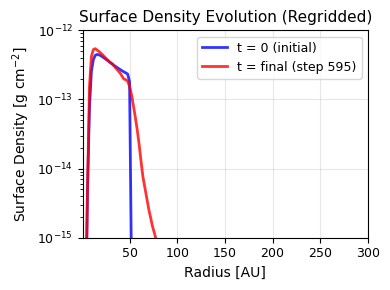

In [9]:
# Load initial data for comparison
output_initial = 'data.0000.dbl.h5'
grid_initial = read_grid(output_initial)
data_initial = read_data(output_initial, grid_initial)

# Function to regrid from spherical to Cartesian and calculate surface density
def calculate_surface_density_regridded(data, grid, nx=250, nz=500):
    """
    Regrid data from spherical (r,θ) to Cartesian grid and calculate surface density
    
    Parameters:
    -----------
    data : dict
        Data dictionary containing density
    grid : dict  
        Grid dictionary containing spherical coordinates (r, th)
    nx : int
        Number of grid points in x (radial) direction
    nz : int
        Number of grid points in z (vertical) direction
        
    Returns:
    --------
    r_cart : array
        Radial coordinates of Cartesian grid
    surface_density_cart : array
        Surface density on Cartesian grid
    """
    from scipy.interpolate import griddata
    
    # Get spherical coordinates
    r_sph = grid['r']  # Spherical radius
    th_sph = grid['th']  # Theta (polar angle)
    
    # Convert spherical to cylindrical coordinates
    # X = r * sin(θ) (cylindrical radius)
    # Z = r * cos(θ) (vertical height)
    X_sph = r_sph * np.sin(th_sph)
    Z_sph = r_sph * np.cos(th_sph)
    
    # Define Cartesian grid limits
    x_max = X_sph.max() * 0.99999
    z_max = Z_sph.max() * 0.99999
    
    x_cart = np.linspace(0, x_max, nx)  # Cylindrical radius
    z_cart = np.linspace(0, z_max, nz)  # Vertical height
    
    X_cart, Z_cart = np.meshgrid(x_cart, z_cart)
    
    # Flatten arrays for interpolation
    points = np.column_stack((X_sph.ravel(), Z_sph.ravel()))
    values = data["density"].ravel()
    xi = np.column_stack((X_cart.ravel(), Z_cart.ravel()))
    
    # Interpolate density onto Cartesian grid
    density_cart = griddata(points, values, xi, method='linear', fill_value=0.0)
    density_cart = density_cart.reshape(nz, nx)
    
    # Calculate surface density by integrating vertically
    # Factor of 2 accounts for symmetry (upper + lower half)
    dz_cart = z_cart[1] - z_cart[0]  # Grid spacing in z
    surface_density_cart = 2 * np.trapz(density_cart, dx=dz_cart * u.cm.to(u.AU), axis=0)
    
    # Convert x coordinates to AU
    r_cart = x_cart * u.cm.to(u.AU)
    
    return r_cart, surface_density_cart

# Calculate surface density profiles with regridding
# For the final step (already loaded)
r_final, surface_density_final = calculate_surface_density_regridded(data, grid)

# For the initial step  
r_initial, surface_density_initial = calculate_surface_density_regridded(data_initial, grid_initial)

# Create comparison plot
plt.figure(figsize=(4, 3))

# Plot both profiles
plt.semilogy(r_initial, surface_density_initial, 'b-', linewidth=2, label='t = 0 (initial)', alpha=0.8)
plt.semilogy(r_final, surface_density_final, 'r-', linewidth=2, label=f't = final (step 595)', alpha=0.8)

# Add formatting
plt.xlabel('Radius [AU]', fontsize=10)
plt.ylabel('Surface Density [g cm$^{-2}$]', fontsize=10)
plt.title('Surface Density Evolution (Regridded)', fontsize=11)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.xlim(1, 300)
plt.ylim(1.e-15, 1e-12)
plt.tick_params(labelsize=9)
plt.tight_layout()

# Print some statistics
print("Surface Density Comparison (Regridded from Spherical 250x500 grid):")
print("-" * 60)
print(f"Initial step (t=0):")
print(f"  Min surface density: {surface_density_initial.min():.2e} g/cm²")
print(f"  Max surface density: {surface_density_initial.max():.2e} g/cm²")
print(f"  Total mass: {np.trapz(surface_density_initial * 2 * np.pi * r_initial * u.AU.to(u.cm), r_initial * u.AU.to(u.cm)) / u.Msun.to(u.g):.3f} M☉")

print(f"\nFinal step (step 595):")
print(f"  Min surface density: {surface_density_final.min():.2e} g/cm²")
print(f"  Max surface density: {surface_density_final.max():.2e} g/cm²")
print(f"  Total mass: {np.trapz(surface_density_final * 2 * np.pi * r_final * u.AU.to(u.cm), r_final * u.AU.to(u.cm)) / u.Msun.to(u.g):.3f} M☉")

# Calculate mass loss
initial_mass = np.trapz(surface_density_initial * 2 * np.pi * r_initial * u.AU.to(u.cm), r_initial * u.AU.to(u.cm)) / u.Msun.to(u.g)
final_mass = np.trapz(surface_density_final * 2 * np.pi * r_final * u.AU.to(u.cm), r_final * u.AU.to(u.cm)) / u.Msun.to(u.g)
mass_lost = initial_mass - final_mass

print(f"\nMass Evolution:")
print(f"  Mass lost: {mass_lost:.4f} M☉")
print(f"  Fraction lost: {mass_lost/initial_mass*100:.2f}%")

print(f"\nGrid Information:")
print(f"  Original: Spherical (r, θ) coordinates")
print(f"  Regridded: Cartesian 250 (radial) × 500 (vertical)")
print(f"  Radial range: {r_initial.min():.1f} - {r_initial.max():.1f} AU")

plt.savefig('../surface_density_evolution_regridded.pdf', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_81917/1129411550.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  surface_density_cart = 2 * np.trapz(density_cart, dx=dz_cart * u.cm.to(u.AU), axis=0)


Surface Density Comparison (Regridded from Spherical 250x500 grid):
------------------------------------------------------------
Initial step (t=0):
  Min surface density: 0.00e+00 g/cm²
  Max surface density: 6.82e-13 g/cm²
  Total mass: 0.000 M☉

Final step (step 595):
  Min surface density: 0.00e+00 g/cm²
  Max surface density: 6.08e-13 g/cm²
  Total mass: 0.000 M☉

Mass Evolution:
  Mass lost: 0.0000 M☉
  Fraction lost: 1.69%

Grid Information:
  Original: Spherical (r, θ) coordinates
  Regridded: Cartesian 250 (radial) × 500 (vertical)
  Radial range: 0.0 - 298.1 AU


/tmp/ipykernel_81917/1129411550.py:99: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  Total mass: {np.trapz(surface_density_initial * 2 * np.pi * r_initial * u.AU.to(u.cm), r_initial * u.AU.to(u.cm)) / u.Msun.to(u.g):.3f} M☉")
/tmp/ipykernel_81917/1129411550.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  Total mass: {np.trapz(surface_density_final * 2 * np.pi * r_final * u.AU.to(u.cm), r_final * u.AU.to(u.cm)) / u.Msun.to(u.g):.3f} M☉")
/tmp/ipykernel_81917/1129411550.py:107: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  initial_mass = np.trapz(surface_density_initial * 2 * np.pi * r_initial * u.AU.to(u.cm), r_initial * u.AU.to(u.cm)) / u.Msun.to(u.g)
/tmp/ipykernel_81917/1129411550.py:108

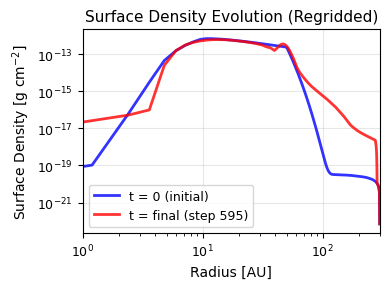

In [ ]:
# Load initial data for comparison
output_initial = 'data.0000.dbl.h5'
grid_initial = read_grid(output_initial)
data_initial = read_data(output_initial, grid_initial)

# Function to regrid from spherical to Cartesian and calculate surface density
def calculate_surface_density_regridded(data, grid, nx=250, nz=500):
    """
    Regrid data from spherical (r,θ) to Cartesian grid and calculate surface density
    
    Parameters:
    -----------
    data : dict
        Data dictionary containing density
    grid : dict  
        Grid dictionary containing spherical coordinates (r, th)
    nx : int
        Number of grid points in x (radial) direction
    nz : int
        Number of grid points in z (vertical) direction
        
    Returns:
    --------
    r_cart : array
        Radial coordinates of Cartesian grid
    surface_density_cart : array
        Surface density on Cartesian grid
    """
    from scipy.interpolate import griddata
    
    # Get spherical coordinates
    r_sph = grid['r']  # Spherical radius
    th_sph = grid['th']  # Theta (polar angle)
    
    # Convert spherical to cylindrical coordinates
    # X = r * sin(θ) (cylindrical radius)
    # Z = r * cos(θ) (vertical height)
    X_sph = r_sph * np.sin(th_sph)
    Z_sph = r_sph * np.cos(th_sph)
    
    # Define Cartesian grid limits
    x_max = X_sph.max() * 0.99999
    z_max = Z_sph.max() * 0.99999
    
    x_cart = np.linspace(0, x_max, nx)  # Cylindrical radius
    z_cart = np.linspace(0, z_max, nz)  # Vertical height
    
    X_cart, Z_cart = np.meshgrid(x_cart, z_cart)
    
    # Flatten arrays for interpolation
    points = np.column_stack((X_sph.ravel(), Z_sph.ravel()))
    values = data["density"].ravel()
    xi = np.column_stack((X_cart.ravel(), Z_cart.ravel()))
    
    # Interpolate density onto Cartesian grid
    density_cart = griddata(points, values, xi, method='linear', fill_value=0.0)
    density_cart = density_cart.reshape(nz, nx)
    
    # Calculate surface density by integrating vertically
    # Factor of 2 accounts for symmetry (upper + lower half)
    dz_cart = z_cart[1] - z_cart[0]  # Grid spacing in z
    surface_density_cart = 2 * np.trapz(density_cart, dx=dz_cart * u.cm.to(u.AU), axis=0)
    
    # Convert x coordinates to AU
    r_cart = x_cart * u.cm.to(u.AU)
    
    return r_cart, surface_density_cart

# Calculate surface density profiles with regridding
# For the final step (already loaded)
r_final, surface_density_final = calculate_surface_density_regridded(data, grid)

# For the initial step  
r_initial, surface_density_initial = calculate_surface_density_regridded(data_initial, grid_initial)

# Create comparison plot
plt.figure(figsize=(4, 3))

# Plot both profiles
plt.loglog(r_initial, surface_density_initial, 'b-', linewidth=2, label='t = 0 (initial)', alpha=0.8)
plt.loglog(r_final, surface_density_final, 'r-', linewidth=2, label=f't = final (step 595)', alpha=0.8)

# Add formatting
plt.xlabel('Radius [AU]', fontsize=10)
plt.ylabel('Surface Density [g cm$^{-2}$]', fontsize=10)
plt.title('Surface Density Evolution (Regridded)', fontsize=11)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.xlim(1, 300)
plt.tick_params(labelsize=9)
plt.tight_layout()

# Print some statistics
print("Surface Density Comparison (Regridded from Spherical 250x500 grid):")
print("-" * 60)
print(f"Initial step (t=0):")
print(f"  Min surface density: {surface_density_initial.min():.2e} g/cm²")
print(f"  Max surface density: {surface_density_initial.max():.2e} g/cm²")
print(f"  Total mass: {np.trapz(surface_density_initial * 2 * np.pi * r_initial * u.AU.to(u.cm), r_initial * u.AU.to(u.cm)) / u.Msun.to(u.g):.3f} M☉")

print(f"\nFinal step (step 595):")
print(f"  Min surface density: {surface_density_final.min():.2e} g/cm²")
print(f"  Max surface density: {surface_density_final.max():.2e} g/cm²")
print(f"  Total mass: {np.trapz(surface_density_final * 2 * np.pi * r_final * u.AU.to(u.cm), r_final * u.AU.to(u.cm)) / u.Msun.to(u.g):.3f} M☉")

# Calculate mass loss
initial_mass = np.trapz(surface_density_initial * 2 * np.pi * r_initial * u.AU.to(u.cm), r_initial * u.AU.to(u.cm)) / u.Msun.to(u.g)
final_mass = np.trapz(surface_density_final * 2 * np.pi * r_final * u.AU.to(u.cm), r_final * u.AU.to(u.cm)) / u.Msun.to(u.g)
mass_lost = initial_mass - final_mass

print(f"\nMass Evolution:")
print(f"  Mass lost: {mass_lost:.4f} M☉")
print(f"  Fraction lost: {mass_lost/initial_mass*100:.2f}%")

print(f"\nGrid Information:")
print(f"  Original: Spherical (r, θ) coordinates")
print(f"  Regridded: Cartesian 250 (radial) × 500 (vertical)")
print(f"  Radial range: {r_initial.min():.1f} - {r_initial.max():.1f} AU")

plt.savefig('../surface_density_evolution_regridded.pdf', dpi=300, bbox_inches='tight')
plt.show()

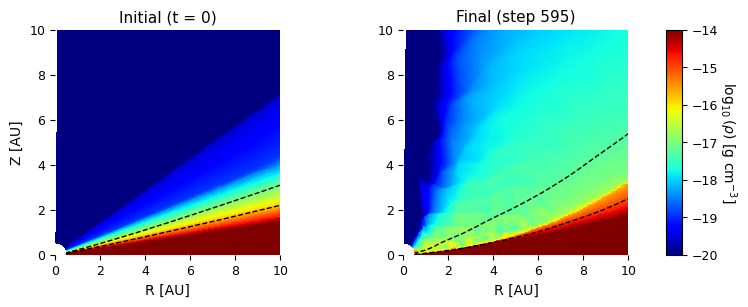

2D Density Evolution Statistics:
----------------------------------------
Initial density range: 5.94e-23 - 1.14e-12 g/cm³
Final density range: 5.91e-23 - 5.71e-12 g/cm³
Midplane density at 10 AU:
  Initial: 1.14e-12 g/cm³
  Final: 5.51e-13 g/cm³
  Ratio (final/initial): 0.485
Midplane density at 50 AU:
  Initial: 2.79e-14 g/cm³
  Final: 2.44e-14 g/cm³
  Ratio (final/initial): 0.873
Midplane density at 100 AU:
  Initial: 1.74e-20 g/cm³
  Final: 4.33e-17 g/cm³
  Ratio (final/initial): 2485.448


In [17]:
# Create 2D density comparison plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Plot parameters
vmin, vmax = -20, -14
cmap = plt.cm.jet

# Initial density (left panel)
ax = axes[0]
X_AU_initial = (grid_initial["X"] * u.cm).to(u.AU).value
Z_AU_initial = (grid_initial["Z"] * u.cm).to(u.AU).value
density_initial = np.log10(data_initial["density"])

plot1 = ax.pcolormesh(X_AU_initial, Z_AU_initial, density_initial, 
                      vmin=vmin, vmax=vmax, cmap=cmap)

# Add column density contours
vals = [5.e20, 1.e22]
contours1 = ax.contour(X_AU_initial, Z_AU_initial, data_initial["column_density"], 
                       vals, linestyles='dashed', colors='black', linewidths=1)

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.set_xlabel('R [AU]', fontsize=10)
ax.set_ylabel('Z [AU]', fontsize=10)
ax.set_title('Initial (t = 0)', fontsize=11)
ax.tick_params(labelsize=9)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Final density (right panel)
ax = axes[1]
X_AU_final = (grid["X"] * u.cm).to(u.AU).value
Z_AU_final = (grid["Z"] * u.cm).to(u.AU).value
density_final = np.log10(data["density"])

plot2 = ax.pcolormesh(X_AU_final, Z_AU_final, density_final, 
                      vmin=vmin, vmax=vmax, cmap=cmap)

# Add column density contours
contours2 = ax.contour(X_AU_final, Z_AU_final, data["column_density"], 
                       vals, linestyles='dashed', colors='black', linewidths=1)

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.set_xlabel('R [AU]', fontsize=10)
ax.set_title('Final (step 595)', fontsize=11)
ax.tick_params(labelsize=9)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Add colorbar
plt.subplots_adjust(left=0.08, bottom=0.15, right=0.85, top=0.9, wspace=0.3)
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.75])
cbar = fig.colorbar(plot2, cax=cbar_ax, orientation='vertical')
cbar.set_label('$\\log_{10}(\\rho)$ [g cm$^{-3}$]', fontsize=10, rotation=270, labelpad=15)
cbar.ax.tick_params(labelsize=9)

plt.savefig('../density_evolution_2d.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print some statistics about the density evolution
print("2D Density Evolution Statistics:")
print("-" * 40)
print(f"Initial density range: {data_initial['density'].min():.2e} - {data_initial['density'].max():.2e} g/cm³")
print(f"Final density range: {data['density'].min():.2e} - {data['density'].max():.2e} g/cm³")

# Calculate density at specific radii for comparison
r_compare = [10, 50, 100]  # AU
for r_au in r_compare:
    # Find closest grid point at midplane (θ ≈ π/2)
    midplane_idx = np.argmin(np.abs(grid_initial['th'][:, 0] - np.pi/2))
    r_idx_initial = np.argmin(np.abs((grid_initial['r'][midplane_idx, :] * u.cm).to(u.AU).value - r_au))
    r_idx_final = np.argmin(np.abs((grid['r'][midplane_idx, :] * u.cm).to(u.AU).value - r_au))
    
    rho_initial = data_initial['density'][midplane_idx, r_idx_initial]
    rho_final = data['density'][midplane_idx, r_idx_final]
    
    print(f"Midplane density at {r_au} AU:")
    print(f"  Initial: {rho_initial:.2e} g/cm³")
    print(f"  Final: {rho_final:.2e} g/cm³") 
    print(f"  Ratio (final/initial): {rho_final/rho_initial:.3f}")